# TAREA 1: Análisis de Rendimiento y Paralelización - Conjunto de Mandelbrot

**Asignatura:** Procesamiento Paralelo de Datos - Curso 2025/2026

**Descripción del caso de uso:**

El conjunto de Mandelbrot es un fractal definido en el plano complejo. Para cada punto $c=x+y_i$, iteramos la fórmula $z_{n+1}=z_n^2+c$ partiendo de $z_0=0$. Si tras un número máximo de iteraciones $|z|$ no supera 2, el punto pertenece al conjunto.

Este problema es ideal para análisis de rendimiento y paralelización porque:
- El cómputo es independiente píxel a píxel (embarrassingly parallel).
- Los bucles anidados en Python puro son un cuello de botella claro.
- Se puede dividir la imagen por filas entre procesos de forma natural.
- Existen librerías optimizadas como `NumPy` o `numba` que permiten comparar diferentes enfoques.

**Estructura del notebook:**

1. Paso 0: Implementación secuencial en Python puro.
2. Paso 1: Profiling (cProfile + `line_profiler`)
3. Paso 2: Paralelización con multiprocessing
4. Paso 3: Optimización con librerías especializadas (`NumPy` vectorizado)
5. Paso 4: Actividades opcionales:

   - OP1: Análisis de escalabilidad + Ley de Amdahl
   - OP2: `numba` + `multiprocessing`
   - OP3: Alternativas (`joblib`)
   - OP4: Comparativa visual de todos los enfoques

---

## Paso 0: Implementación Secuencial (Python puro)

Implementamos el cálculo del conjunto de Mandelbrot usando **exclusivamente** bucles y operaciones básicas de Python, sin llamadas a librerías externas (valo para visualización al final). Esto nos dará la línea base (baseline) contra la que mediremos todas las optimizaciones posteriores.

In [1]:
# === IMPORTS BÁSICOS ===
# Solo usamos librerías estándasr para el cómputo.
# matplotlib y numpy se usan SOLO para visualización y guardado, no para el cálculo.
import time
import numpy as np
import matplotlib.pyplot as plt

### 0.1: Parámetros del fractal

Definimos los parámetros que controlan la resolución y el rango del fractal.
- `WIDTH` y `HEIGHT`: resolución de la imagen en píxeles.
- `MAX_ITER`: número máximo de iteraciones por píxel. Más iteraciones = más detalle en los bordes del conjunto, pero más tiempo de cómputo.
- `X_MIN, X_MAX, Y_MIN, Y_MAX`: ventana del plano complejo que vamos a renderizar. Los valores por defecto muestran el conjunto de Mandelbrot completo.

In [2]:
# --- Parámetros de la imagen ---
# Usamos una resolución moderada para que el profiling no tarde demasiado,
# pero lo suficiente para que el tiempo de cómputo sea significativo (~segundos).
WIDTH = 800     # Número de píxeles en el eje horizontal (eje real)
HEIGHT = 600    # Número de píxeles en el eje vertical (eje imaginario)
MAX_ITER = 200  # Máximo de iteraciones antes de declarar que un punto pertenece al conjunto

# --- Ventana del plano complejo ---
# Estos valores encuadran el conjunto de Mandelbrot completo centrado en el origen.
X_MIN = -2.5    # Límite izquierdo del eje real
X_MAX = 1.0     # Límite derecho del eje real
Y_MIN = -1.25   # Límite inferior del eje imaginario
Y_MAX = 1.25    # Límite superior del eje imaginario

### 0.2: Función de cómputo por píxel

La función `mandelbrot_pixel` calcula, para un punto del plano complejo, cuántas iteraciones tarda en "escapar" ($|z|>2$). Si no escapa tras `MAX_ITER` iteraciones, devuelve `MAX_ITER` (pertenece al conjunto).

Esta es la **unidad mínima de trabajo** y será el objetivo principal de la paralelización.

In [3]:
def mandelbrot_pixel(c_real: float, c_imag: float, max_iter: int) -> int:
    """
    Calcula el número de iteraciones para un punto del plano complejo.

    Parámetros:
        c_real: Parte real del número complejo c (coordenada x).
        c_imag: Parte imaginaria del número complejo c (coordenada y).
        max_iter: Número máximo de iteraciones permitidas.

    Retorna:
        Número de iteraciones hasta que |z| > 2, o max_iter si no escapa.

    Nota:
        Usamos la condición z_real² y z_imag² > 4.0 en lugar de sqrt(z_real² + z_imag²) > 2.0
        para evitar la costosa operación de raíz cuadrada en cada iteración.
    """
    # Partimos de z_0 = 0 + 0i
    z_real = 0.0
    z_imag = 0.0

    # Iteramos z_{n+1} = z_n² + c hasta que escape o agotemos iteraciones
    for n in range(max_iter):
        # Calculamos z² = (z_real + z_imag * i)²
        # Parte real de z²: z_real² - z_imag²
        # Parte imaginaria de z²: 2 * z_real * z_imag
        z_real_sq = z_real * z_real     # z_real² (lo guardamos para reutilizar)
        z_imag_sq = z_imag * z_imag     # z_imag² (lo guardamos para reutilizar)

        # Condición de escape: |z|² = z_real² + z_imag² > 4.0
        # (equivalente a |z| > 2.0, pero sin calcular la raíz cuadrada)
        if z_real_sq + z_imag_sq > 4.0:
            return n  # El punto ha escapado en la iteración n

        # Actualizamos z: z_{n+1} = z_n² + c
        z_imag = 2.0 * z_real * z_imag + c_imag     # Primero la parte imaginaria (usa z_real original)
        z_real = z_real_sq - z_imag_sq + c_real     # Luego la parte real

    # Si llegamos aquí, el punto no escapó: pertenece al conjunto
    return max_iter

### 0.3: Función de generación de la imagen completa (secuencial)

Recorremos cada píxel de la imagen, convertimos sus coordenadas (filas, columna) a un punto del plano complejo, y calculamos las iteraciones con `mandelbrot_pixel`.

El resultado es una lista de listas (matriz) donde cada valor representa el número de iteraciones de ese píxel.

In [4]:
def mandelbrot_sequential(
    width: int,
    height: int,
    x_min: float,
    x_max: float,
    y_min: float,
    y_max: float,
    max_iter: int
) -> list[list[int]]:
    """
    Parámetros:
        width, height: Dimensiones de la imagen en píxeles.
        x_min, x_max: Rango del eje real (horizontal) del plano complejo
        y_min, y_max: Rango del eje imaginario (vertical) del plano complejo
        max_iter: Máximo de iteraciones por píxel

    Retorna:
        Matriz height x width con el número de iteraciones de cada píxel
    """
    # Inicializamos la imagen como una lista de listas (Python puro, sin numpy)
    image = []

    # Recorremos cada fila (eje Y = eje imaginario)
    for row in range(height):
        # Convertimos la fila a coordenada imaginaria
        # row = 0 corresponde a y_max (parte superior de la imagen)
        # row = height - 1 corresponde a y_min (parte inferior)
        c_imag = y_max - row * (y_max - y_min) / (height - 1)

        # Lista para almacenar los valores de esta fila
        row_data = []

        # Recorremos cada columna (eje X = eje real)
        for col in range(width):
            # Convertimos la columna a coordenada real
            # col = 0 corresponde a x_min (extremos izquierdo)
            # col = width - 1 corresponde a x_max (extremo derecho)
            c_real = x_min + col * (x_max - x_min) / (width - 1)

            # Calculamos las iteraciones para este píxel
            iterations = mandelbrot_pixel(c_real, c_imag, max_iter)

            # Alamacenamos el resultado
            row_data.append(iterations)

        # Añadimos la fila completa a la imagen
        image.append(row_data)

    return image

### 0.4: Ejecución de la versión secuencial y visualización

Ejecutamos el cálculo secuencial y medimos el tiempo con `time.perf_counter()` (más preciso que `time.time()` para medir intervalos cortos).

In [5]:
# --- Ejecución secuencial con medición de tiempo ---
print("=" * 60)
print("PASO 0: Ejecución secuencial (Python puro)")
print("=" * 60)
print(f"Resolución: {WIDTH}×{HEIGHT} píxeles")
print(f"Iteraciones máximas: {MAX_ITER}")
print(f"Ventana compleja: [{X_MIN}, {X_MAX}] × [{Y_MIN}, {Y_MAX}]")
print()

# Medimos el tiempo de ejecución
t_start = time.perf_counter()
image_seq = mandelbrot_sequential(WIDTH, HEIGHT, X_MIN, X_MAX, Y_MIN, Y_MAX, MAX_ITER)
t_end = time.perf_counter()

# Guardamos el tiempo secuencial como referencia para calcular speedups después
tiempo_secuencial = t_end - t_start
print(f"Tiempo secuencial: {tiempo_secuencial:.4f} segundos")

PASO 0: Ejecución secuencial (Python puro)
Resolución: 800×600 píxeles
Iteraciones máximas: 200
Ventana compleja: [-2.5, 1.0] × [-1.25, 1.25]



Tiempo secuencial: 0.8596 segundos


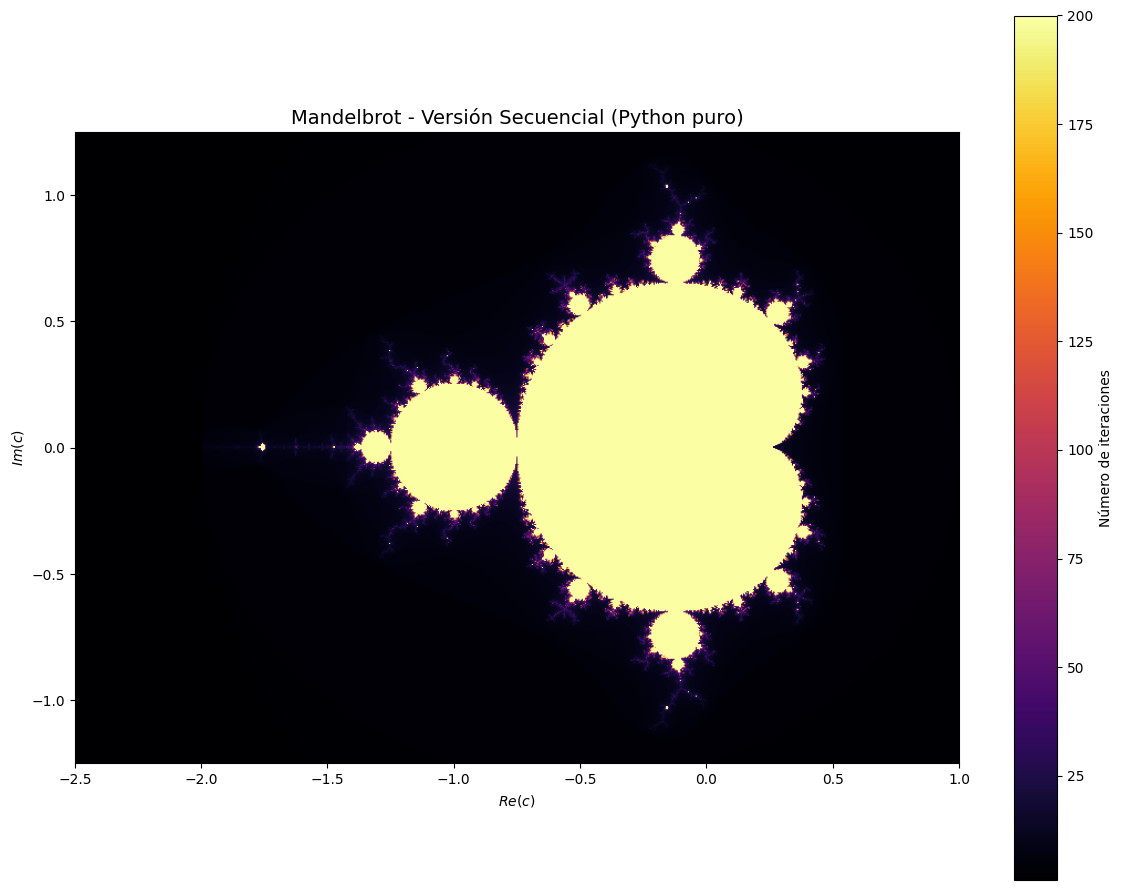

In [6]:
# --- Función auxiliar para visualizar el fractal ---
def plot_mandelbrot(image_data: list[list[int]] | np.ndarray, title: str = "Conjunto de Mandelbrot"):
    """
    Visualiza una imagen del conjunto de Mandelbrot usando matplotlib.

    Parámetros:
        image_data: Matriz con los valores de iteración de cada píxel
        title: Título del gráfico
    """
    plt.figure(figsize=(12, 9))
    # Usamos el colormap 'inferno' que dan un buen contraste para fractales
    # (de negro para MAX_ITER a amarillo brillante para pocas iteraciones)
    plt.imshow(image_data, cmap='inferno', extent=[X_MIN, X_MAX, Y_MIN, Y_MAX])
    plt.colorbar(label="Número de iteraciones")
    plt.title(title, fontsize=14)
    plt.xlabel('$Re(c)$')
    plt.ylabel('$Im(c)$')
    plt.tight_layout()
    plt.show()

# Visualizamos el resultado secuencial
plot_mandelbrot(image_seq, title="Mandelbrot - Versión Secuencial (Python puro)")

---
## Paso 1: Profiling del Código Secuencial

Usamos herramientas de profiling para identificar **exactamente** dónde se gasta el tiempo de ejecución. Emplearemos dos herramientas complementarias

1. **cProfile**: profiling a nivel de función. Nos dice cuánto tiempo total se gasta en cada función y cuántas veces se llama.
2. **line_profiler**: profiling línea a línea. Nos muestra qué líneas concretas dentro de una función son las más costosas.

### 1.1: Profiling con cProfile

In [7]:
import cProfile
import pstats
from io import StringIO

# --- Profiling con cProfile ---
# cProfile instrumenta cada llamada a función y mide:
# - ncalls: número de veces que se llama la función
# - tottime: tiempo total en la función (sin contar subfunciones)
# - cumtime: tiempo acumulado (incluyendo subfunciones)
# - percal: tiempo por llamada

print("=" * 60)
print("=" * 60)